In [16]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog
from skimage import exposure
import pandas as pd
import cv2
import time
import os
from sklearn.metrics import f1_score

HOG_SIZE = 64
CLASS_NAMES = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']



In [2]:
model = joblib.load("hog_svm_baseline.pkl") 
candidatas = pd.read_csv("../candidatas_finales_comunes.csv")

def get_hog_visualization(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face = cv2.resize(gray, (HOG_SIZE, HOG_SIZE))
    face_norm = face / 255.0

    features, hog_image = hog(
        face_norm,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=True
    )
    hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
    return face, hog_image_rescaled, features

def predecir_hog_svm(model, features):
    pred = model.predict([features])[0]
    return CLASS_NAMES[pred]

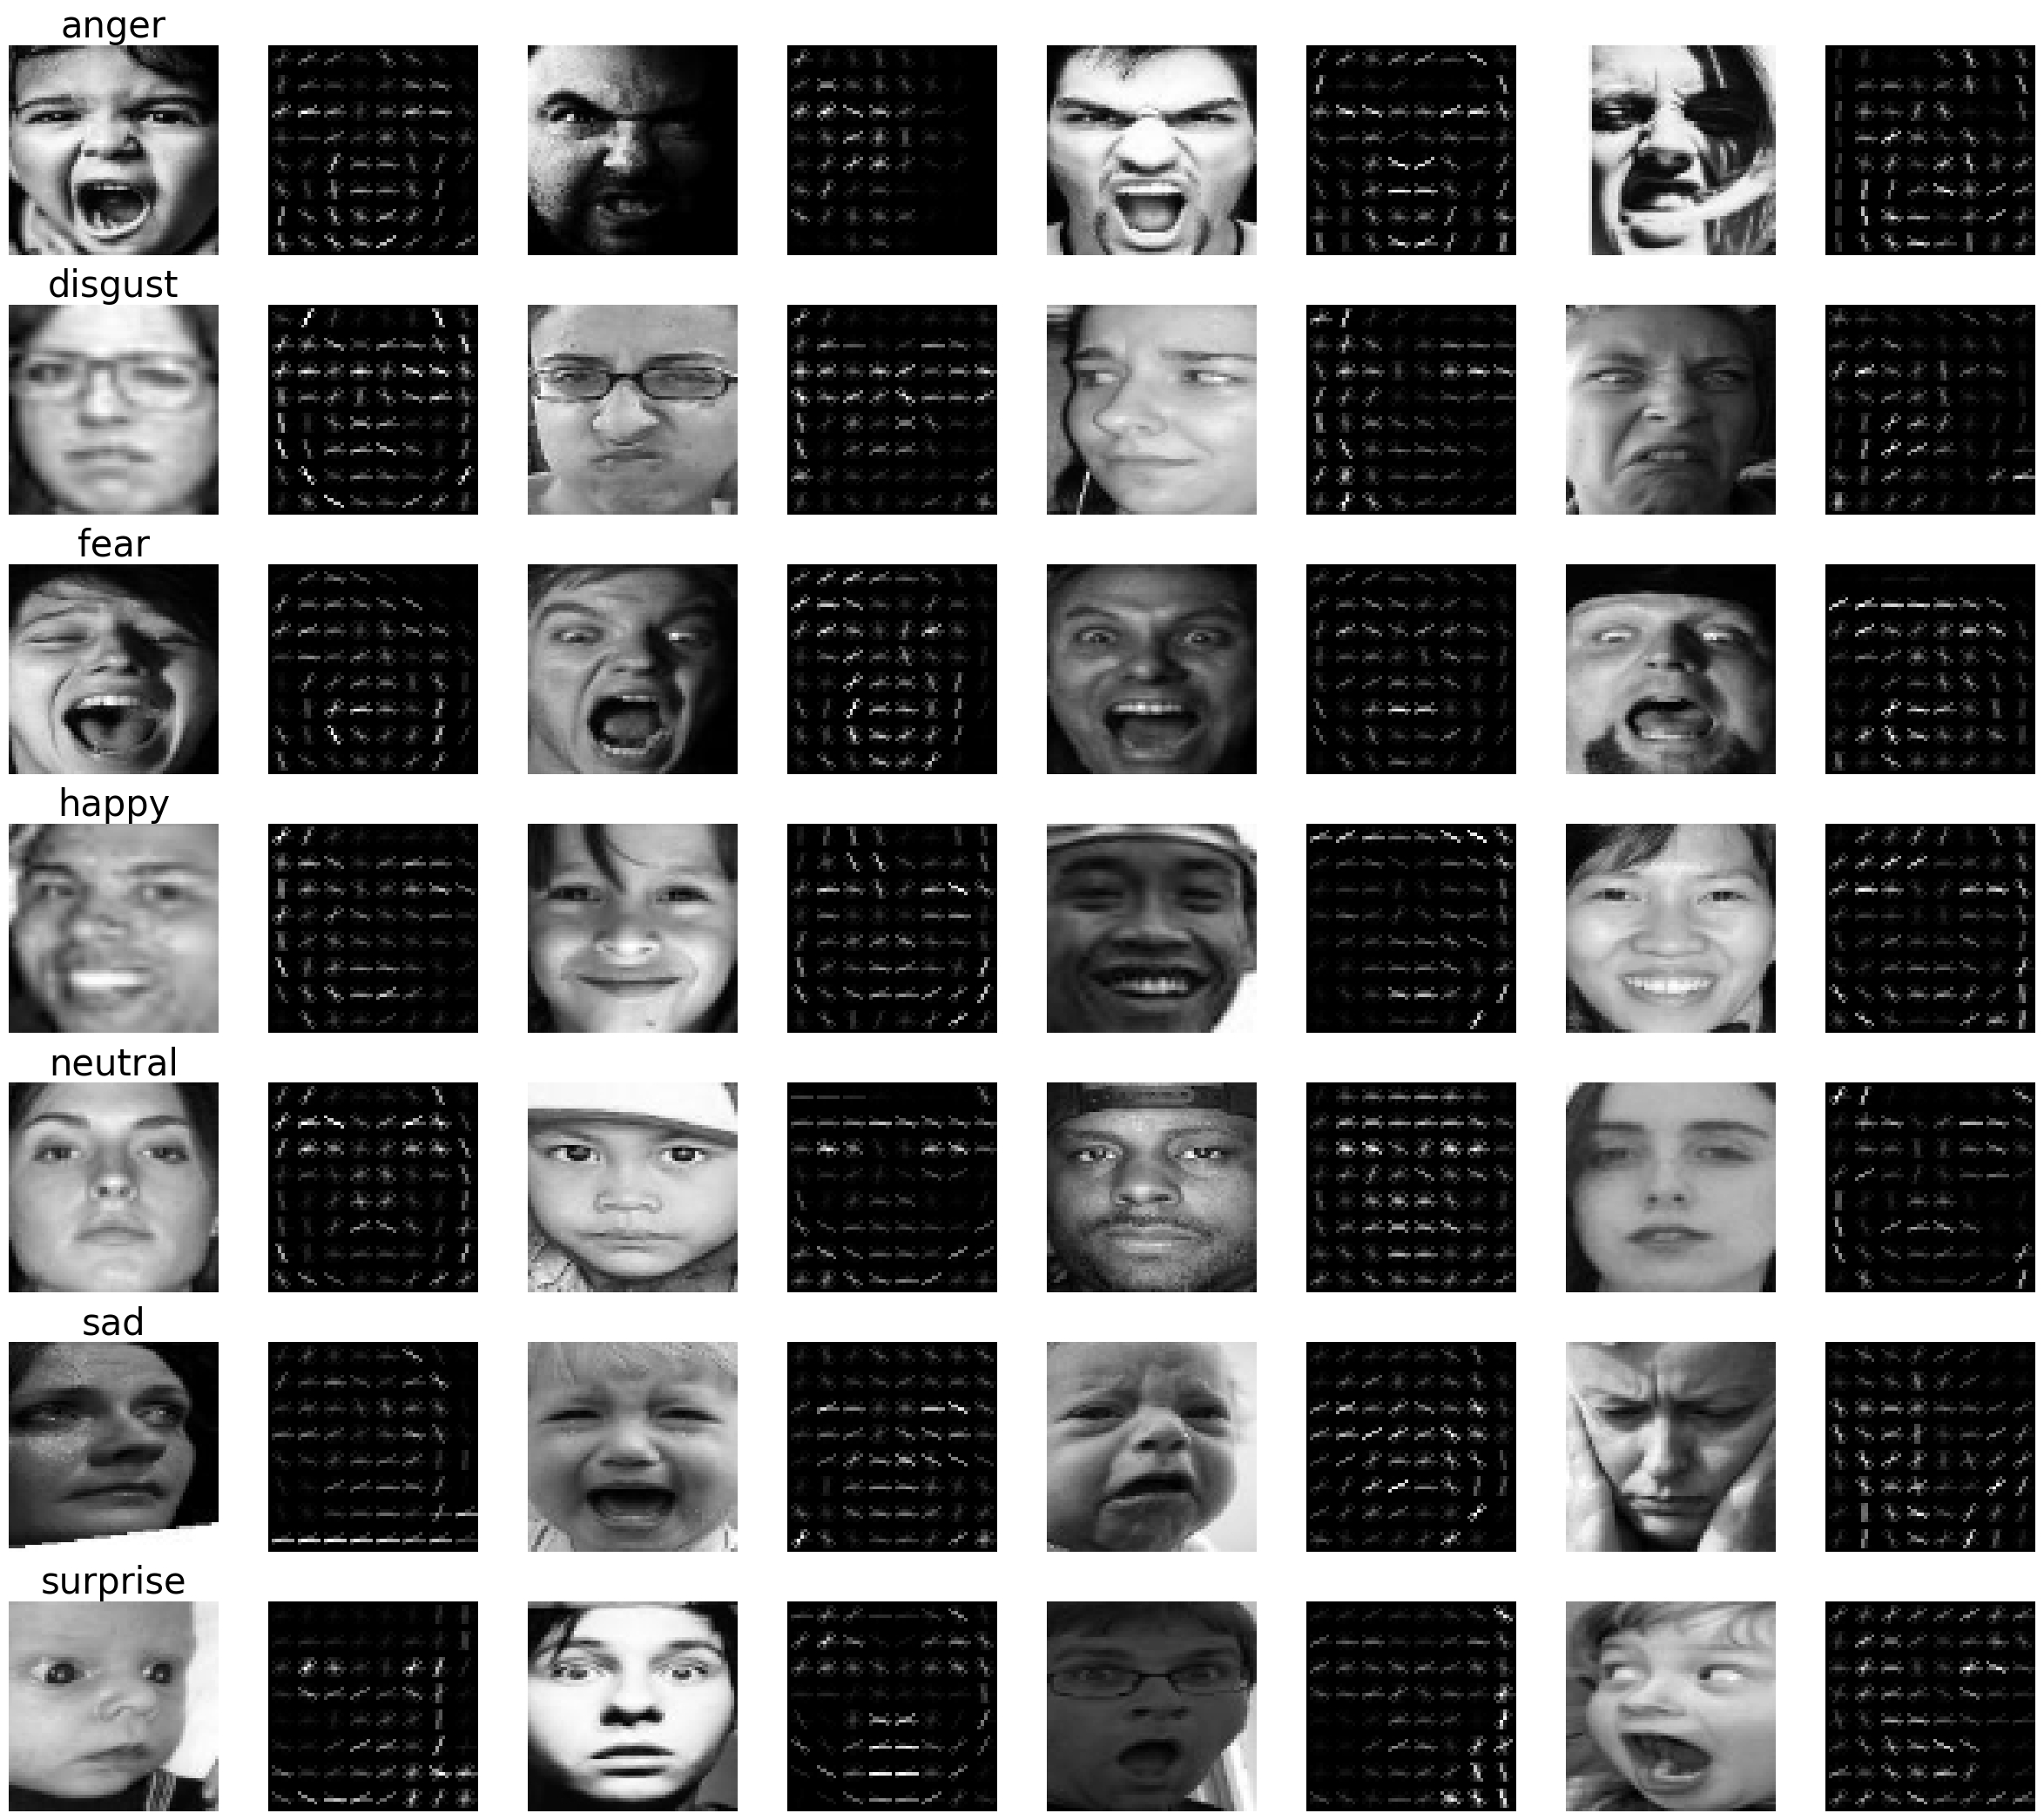

In [9]:
fig, axes = plt.subplots(
    nrows=len(CLASS_NAMES),
    ncols=8,  # 4 imágenes × (original + HOG)
    figsize=(24, len(CLASS_NAMES) * 3)
)

for row_idx, emotion_idx in enumerate(range(len(CLASS_NAMES))):
    emotion_name = CLASS_NAMES[emotion_idx]
    subset = candidatas[candidatas["label_real"] == emotion_idx]

    for col_pair, (_, row) in enumerate(subset.iterrows()):
        if col_pair >= 4:
            break

        face, hog_img, features = get_hog_visualization(row["imagen_path"])
        pred = predecir_hog_svm(model, features)

        col_orig = col_pair * 2
        col_hog  = col_pair * 2 + 1

        axes[row_idx, col_orig].imshow(face, cmap="gray")
        axes[row_idx, col_orig].axis("off")
        if col_pair == 0:
            axes[row_idx, col_orig].set_title(f"{emotion_name}", fontsize=30)


        axes[row_idx, col_hog].imshow(hog_img, cmap="gray")
        axes[row_idx, col_hog].axis("off")

plt.tight_layout()
plt.savefig("hog_explicabilidad.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:


N_RUNS   = 100
N_WARMUP = 10

img = cv2.imread(candidatas["imagen_path"].iloc[0])
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face = cv2.resize(gray, (HOG_SIZE, HOG_SIZE))
face_norm = face / 255.0

def extract_hog(img_norm):
    return hog(
        img_norm,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False
    )

def predict_fn(img_norm):
    features = extract_hog(img_norm)
    return model.predict([features])[0]

times       = []
times_hog   = []
times_svm   = []

for _ in range(N_WARMUP):
    predict_fn(face_norm)

for _ in range(N_RUNS):

    predict_fn(face_norm)  
    start = time.perf_counter()

    t0 = time.perf_counter()
    features = extract_hog(face_norm)
    t1 = time.perf_counter()
    _ = model.predict([features])[0]
    t2 = time.perf_counter()

    times_hog.append((t1 - t0) * 1000)
    times_svm.append((t2 - t1) * 1000)
    times.append((t2 - start) * 1000)

times     = np.array(times)
times_hog = np.array(times_hog)
times_svm = np.array(times_svm)

print("── Pipeline completo (HOG + SVM) ──────────────")
print(f"Latencia media:      {np.mean(times):.3f} ms")
print(f"Desviación estándar: {np.std(times):.3f} ms")
print(f"Mediana (p50):       {np.percentile(times, 50):.3f} ms")
print(f"P95:                 {np.percentile(times, 95):.3f} ms")
print(f"P99:                 {np.percentile(times, 99):.3f} ms")


── Pipeline completo (HOG + SVM) ──────────────
Latencia media:      14.456 ms
Desviación estándar: 2.061 ms
Mediana (p50):       14.196 ms
P95:                 14.650 ms
P99:                 27.450 ms


In [ ]:

HOG_SIZE    = 64
CLASS_NAMES = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
TEST_PATH   = "../RAF_DB/DATASET/test"
OUTPUT_DIR  = "Explicabilidad"


model = joblib.load("hog_svm_baseline.pkl")

def load_paths(dataset_path):
    paths, labels = [], []
    class_names = sorted(os.listdir(dataset_path))
    for label_idx, label in enumerate(class_names):
        label_path = os.path.join(dataset_path, label)
        for img_name in os.listdir(label_path):
            paths.append(os.path.join(label_path, img_name))
            labels.append(label_idx)
    return np.array(paths), np.array(labels)

X_test, y_test = load_paths(TEST_PATH)
print(f"Test set: {len(X_test)} imágenes")

def extract_hog_features(img_gray_norm):
    return hog(
        img_gray_norm,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        visualize=False
    )

def predict_hog_svm(img_path, perturbation_fn=None, **pert_params):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face = cv2.resize(gray, (HOG_SIZE, HOG_SIZE))
    face_norm = face / 255.0

    if perturbation_fn is not None:
        face_norm = perturbation_fn(face_norm, **pert_params)
        face_norm = np.clip(face_norm, 0, 1)

    features = extract_hog_features(face_norm)
    return model.predict([features])[0]


def apply_gaussian_blur(img_norm, kernel_size=5, sigma=1.0):
    kernel_size = int(kernel_size)
    if kernel_size % 2 == 0:
        kernel_size += 1
    return cv2.GaussianBlur(img_norm, (kernel_size, kernel_size), sigma)

def apply_rotation(img_norm, angle_degrees=15):
    h, w = img_norm.shape[:2]
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle_degrees, 1.0)
    return cv2.warpAffine(img_norm, M, (w, h))

def apply_brightness(img_norm, delta=0.3):
    return img_norm + delta

def apply_jpeg_compression(img_norm, quality=50):
    img_uint8 = (img_norm * 255).astype(np.uint8)
    _, encoded = cv2.imencode('.jpg', img_uint8, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
    decoded = cv2.imdecode(encoded, cv2.IMREAD_GRAYSCALE)
    return decoded / 255.0

perturbations = {
    "gaussian_blur_low"   : {"fn": apply_gaussian_blur,    "params": {"kernel_size": 3, "sigma": 0.5}},
    "gaussian_blur_med"   : {"fn": apply_gaussian_blur,    "params": {"kernel_size": 5, "sigma": 1.0}},
    "gaussian_blur_high"  : {"fn": apply_gaussian_blur,    "params": {"kernel_size": 7, "sigma": 2.0}},
    "rotation_low"        : {"fn": apply_rotation,         "params": {"angle_degrees": 10}},
    "rotation_med"        : {"fn": apply_rotation,         "params": {"angle_degrees": 15}},
    "rotation_high"       : {"fn": apply_rotation,         "params": {"angle_degrees": 30}},
    "brightness_low"      : {"fn": apply_brightness,       "params": {"delta": 0.15}},
    "brightness_med"      : {"fn": apply_brightness,       "params": {"delta": 0.3}},
    "brightness_high"     : {"fn": apply_brightness,       "params": {"delta": 0.5}},
    "jpeg_compression_med": {"fn": apply_jpeg_compression, "params": {"quality": 10}},
}


print("\nEvaluando robustez en conjunto de test completo...")

resultados_robustez = []

y_pred_orig  = np.array([predict_hog_svm(p) for p in X_test])
f1_original  = f1_score(y_test, y_pred_orig, average="macro")
acc_original = (y_pred_orig == y_test).mean()

print(f"\nMétricas originales (sin perturbación):")
print(f"  F1-Macro: {f1_original:.4f}")
print(f"  Accuracy: {acc_original:.4f}")

resultados_robustez.append({
    "perturbacion"   : "sin_perturbacion",
    "f1_macro"       : f1_original,
    "accuracy"       : acc_original,
    "degradacion_f1" : 0.0,
    "degradacion_acc": 0.0,
})

for pert_name, pert_config in perturbations.items():
    print(f"\nEvaluando: {pert_name}...", end=" ", flush=True)

    y_pred_pert = np.array([
        predict_hog_svm(p, perturbation_fn=pert_config["fn"], **pert_config["params"])
        for p in X_test
    ])

    f1_pert  = f1_score(y_test, y_pred_pert, average="macro")
    acc_pert = (y_pred_pert == y_test).mean()

    degradacion_f1  = (f1_original - f1_pert) / f1_original * 100
    degradacion_acc = (acc_original - acc_pert) / acc_original * 100

    resultados_robustez.append({
        "perturbacion"   : pert_name,
        "f1_macro"       : f1_pert,
        "accuracy"       : acc_pert,
        "degradacion_f1" : degradacion_f1,
        "degradacion_acc": degradacion_acc,
    })

    print(f"F1={f1_pert:.4f} (↓{degradacion_f1:.1f}%) | Acc={acc_pert:.4f} (↓{degradacion_acc:.1f}%)")


Test set: 3068 imágenes

Evaluando robustez en conjunto de test completo...

Métricas originales (sin perturbación):
  F1-Macro: 0.5859
  Accuracy: 0.7122

Evaluando: gaussian_blur_low... F1=0.5661 (↓3.4%) | Acc=0.7037 (↓1.2%)

Evaluando: gaussian_blur_med... F1=0.4776 (↓18.5%) | Acc=0.6506 (↓8.6%)

Evaluando: gaussian_blur_high... F1=0.3453 (↓41.1%) | Acc=0.5456 (↓23.4%)

Evaluando: rotation_low... F1=0.4320 (↓26.3%) | Acc=0.5893 (↓17.3%)

Evaluando: rotation_med... F1=0.2986 (↓49.0%) | Acc=0.4915 (↓31.0%)

Evaluando: rotation_high... F1=0.1287 (↓78.0%) | Acc=0.2653 (↓62.7%)

Evaluando: brightness_low... F1=0.5797 (↓1.1%) | Acc=0.7053 (↓1.0%)

Evaluando: brightness_med... F1=0.5197 (↓11.3%) | Acc=0.6532 (↓8.3%)

Evaluando: brightness_high... F1=0.3697 (↓36.9%) | Acc=0.4863 (↓31.7%)

Evaluando: jpeg_compression_med... F1=0.4450 (↓24.0%) | Acc=0.6040 (↓15.2%)
